# Do NHL Forwards Score More Points Per Game Than Defensemen?

## Research Question

Do NHL forwards have a higher average points per game (PPG) than defensemen during the 2025–26 regular season?

### Hypotheses

- **H₀ (null hypothesis):** Forwards do not have a higher mean PPG than defensemen.
- **H₁ (alternative hypothesis):** Forwards have a higher mean PPG than defensemen.

## Data

This analysis uses NHL skater statistics for the 2025–2026 regular season.


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
import numpy as np

df = pd.read_csv("../data/skaters_by_season_summary.csv")

df.head()

,assists,evGoals,evPoints,faceoffWinPct,gameWinningGoals,gamesPlayed,goals,lastName,otGoals,penaltyMinutes,...,ppPoints,seasonId,shGoals,shPoints,shootingPct,shootsCatches,shots,skaterFullName,teamAbbrevs,timeOnIcePerGame
0,10,NaN,NaN,NaN,2,21,36,Denneny,0,80,...,NaN,19171918,NaN,NaN,NaN,L,NaN,Cy Denneny,SEN,NaN
1,10,NaN,NaN,NaN,1,21,17,Cameron,0,28,...,NaN,19171918,NaN,NaN,NaN,R,NaN,Harry Cameron,TAN,NaN
2,3,NaN,NaN,NaN,1,18,3,Mummery,0,41,...,NaN,19171918,NaN,NaN,NaN,L,NaN,Harry Mummery,TAN,NaN
3,9,NaN,NaN,NaN,1,21,11,Meeking,0,28,...,NaN,19171918,NaN,NaN,NaN,L,NaN,Harry Meeking,TAN,NaN
4,1,NaN,NaN,NaN,0,18,2,Laviolette,0,6,...,NaN,19171918,NaN,NaN,NaN,R,NaN,Jack Laviolette,MTL,NaN


In [2]:
print(df.columns)
print(df["seasonId"].unique())

Index(['assists', 'evGoals', 'evPoints', 'faceoffWinPct', 'gameWinningGoals',
       'gamesPlayed', 'goals', 'lastName', 'otGoals', 'penaltyMinutes',
       'playerId', 'plusMinus', 'points', 'pointsPerGame', 'positionCode',
       'ppGoals', 'ppPoints', 'seasonId', 'shGoals', 'shPoints', 'shootingPct',
       'shootsCatches', 'shots', 'skaterFullName', 'teamAbbrevs',
       'timeOnIcePerGame'],
      dtype='str')
[19171918 19181919 19191920 19201921 19211922 19221923 19231924 19241925
 19251926 19261927 19271928 19281929 19291930 19301931 19311932 19321933
 19331934 19341935 19351936 19361937 19371938 19381939 19391940 19401941
 19411942 19421943 19431944 19441945 19451946 19461947 19471948 19481949
 19491950 19501951 19511952 19521953 19531954 19541955 19551956 19561957
 19571958 19581959 19591960 19601961 19611962 19621963 19631964 19641965
 19651966 19661967 19671968 19681969 19691970 19701971 19711972 19721973
 19731974 19741975 19751976 19761977 19771978 19781979 19791980 1980198

### Data filtering

In [3]:
# create a new DataFrame containing only the 2025-2026 season
df_2526 = df[df["seasonId"] == 20252026].copy()
df_2526.shape

(940, 26)

### Position grouping

In [4]:
# show the counts of each position code in the 2025-2026 season
df_2526["positionCode"].value_counts()


positionCode
D    319
C    300
L    167
R    154
Name: count, dtype: int64

For our analysis, we will group C, L, and R as forwards, and D as defensemen.

In [5]:
df_2526["positionGroup"] = df_2526["positionCode"].map({
    "C": "Forward",
    "L": "Forward",
    "R": "Forward",
    "D": "Defenseman"
})
df_2526["positionGroup"].value_counts()

positionGroup
Forward       621
Defenseman    319
Name: count, dtype: int64

In [6]:
# Check for missing values in the "pointsPerGame" column
df_2526["pointsPerGame"].isna().sum()

np.int64(0)

### Descriptive statistics

In [7]:
print(f"{df_2526['pointsPerGame'].describe()}\n\n{df_2526['gamesPlayed'].describe()}")

count    940.000000
mean       0.377961
std        0.305604
min        0.000000
25%        0.166660
50%        0.294225
75%        0.514385
max        2.000000
Name: pointsPerGame, dtype: float64

count    940.000000
mean      50.242553
std       29.067413
min        1.000000
25%       22.750000
50%       61.000000
75%       77.000000
max       83.000000
Name: gamesPlayed, dtype: float64


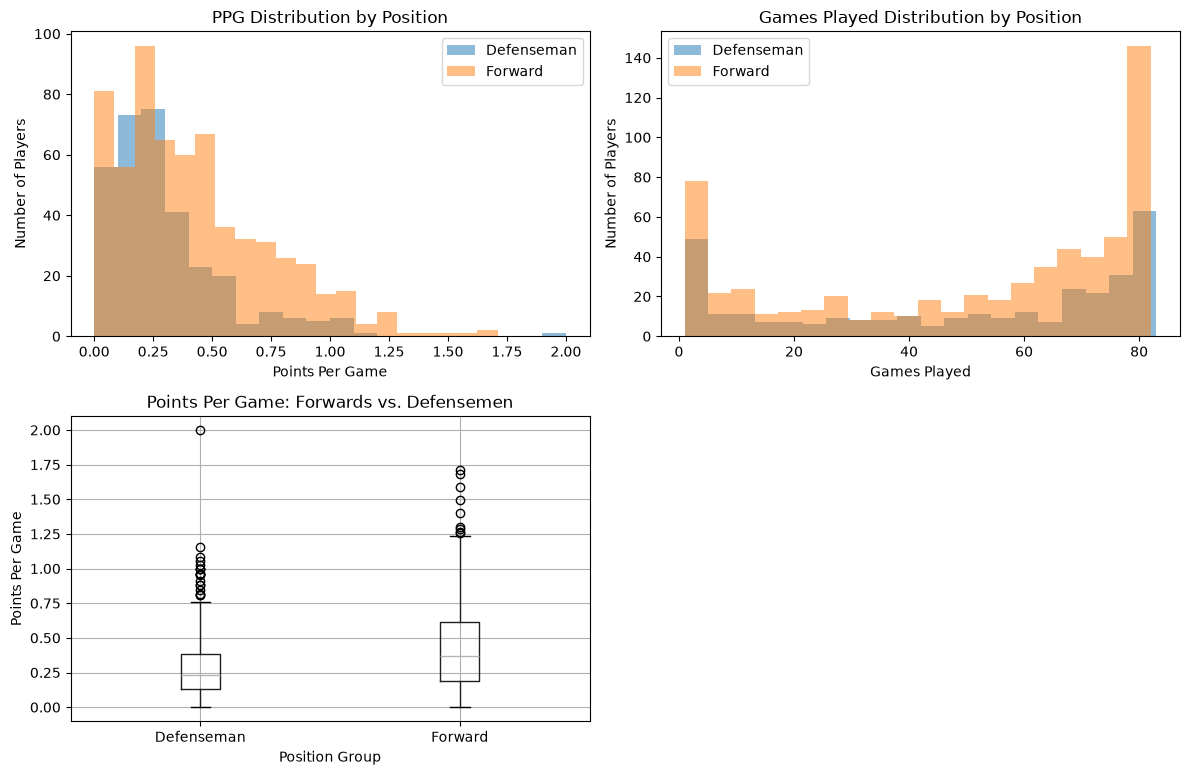

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()  # turns 2x2 grid into a flat list: axes[0..3]

df_2526.groupby("positionGroup")["pointsPerGame"].plot(
    kind="hist",
    alpha=0.5,
    bins=20,
    legend=True,
    ax=axes[0]
)
axes[0].set_xlabel("Points Per Game")
axes[0].set_ylabel("Number of Players")
axes[0].set_title("PPG Distribution by Position")

df_2526.groupby("positionGroup")["gamesPlayed"].plot(
    kind="hist",
    alpha=0.5,
    bins=20,
    legend=True,
    ax=axes[1]
)
axes[1].set_xlabel("Games Played")
axes[1].set_ylabel("Number of Players")
axes[1].set_title("Games Played Distribution by Position")

df_2526.boxplot(
    column="pointsPerGame",
    by="positionGroup",
    ax=axes[2]
)
axes[2].set_title("Points Per Game: Forwards vs. Defensemen")
axes[2].set_xlabel("Position Group")
axes[2].set_ylabel("Points Per Game")

axes[3].axis("off")  # hide the unused 4th subplot

plt.suptitle("")  # removes pandas' auto-added "Boxplot grouped by..." title
plt.tight_layout()
plt.show()

In [9]:
# check for outliers in the "pointsPerGame" column
df_2526[df_2526["pointsPerGame"] > 1.24]

,assists,evGoals,evPoints,faceoffWinPct,gameWinningGoals,gamesPlayed,goals,lastName,otGoals,penaltyMinutes,...,seasonId,shGoals,shPoints,shootingPct,shootsCatches,shots,skaterFullName,teamAbbrevs,timeOnIcePerGame,positionGroup
46838,90,34.0,82.0,0.49512,4,82,48,McDavid,1,44,...,20252026,1.0,2.0,0.15686,L,306.0,Connor McDavid,EDM,1379.1219,Forward
46924,62,18.0,54.0,0.56935,3,65,35,Draisaitl,1,26,...,20252026,1.0,1.0,0.18817,L,186.0,Leon Draisaitl,EDM,1294.5076,Forward
47116,71,19.0,67.0,0.22222,4,77,29,Pastrnak,1,72,...,20252026,0.0,0.0,0.11111,R,261.0,David Pastrnak,BOS,1239.3376,Forward
47129,86,35.0,92.0,0.00000,8,76,44,Kucherov,2,50,...,20252026,1.0,1.0,0.19047,L,231.0,Nikita Kucherov,TBL,1220.1052,Forward
47183,70,37.0,82.0,0.48638,5,82,45,Celebrini,2,44,...,20252026,0.0,0.0,0.15679,L,287.0,Macklin Celebrini,SJS,1278.9512,Forward
47212,50,22.0,52.0,0.34772,5,61,27,Hughes,1,10,...,20252026,1.0,2.0,0.11842,L,228.0,Jack Hughes,NJD,1278.9344,Forward
47243,62,29.0,76.0,0.42857,5,78,38,Necas,0,30,...,20252026,0.0,0.0,0.18446,R,206.0,Martin Necas,COL,1289.8846,Forward
47468,1,1.0,2.0,NaN,0,1,1,Bonk,0,0,...,20252026,0.0,0.0,1.00000,R,1.0,Oliver Bonk,PHI,988.0000,Defenseman
47490,74,42.0,97.0,0.51049,7,80,53,MacKinnon,1,39,...,20252026,0.0,0.0,0.15142,R,350.0,Nathan MacKinnon,COL,1335.7125,Forward
47549,67,29.0,80.0,0.46661,6,82,36,Scheifele,1,43,...,20252026,0.0,1.0,0.20571,R,175.0,Mark Scheifele,WPG,1290.2439,Forward


In [10]:
# checking for players with very few games played, who might skew PPG
df_2526["gamesPlayed"].value_counts().sort_index().head(20)

gamesPlayed
1     32
2     22
3     34
4     24
5     15
6     10
7      5
8      7
9     11
10     6
11    10
12     8
13    11
14     5
15     6
16     3
17     4
18     5
19     6
20     4
Name: count, dtype: int64

In [11]:
# let's see how much data we would lose with different thresholds
for minimum_games in [1, 5, 10, 15, 20]:
    count = (df_2526["gamesPlayed"] >= minimum_games).sum()
    print(f"{minimum_games}+ games: {count} players ({round(count / len(df_2526) * 100, 2)}% of all players)")

1+ games: 940 players (100.0% of all players)
5+ games: 828 players (88.09% of all players)
10+ games: 780 players (82.98% of all players)
15+ games: 740 players (78.72% of all players)
20+ games: 716 players (76.17% of all players)


We will use 10+ games as a threshold. It removes players with very limited playing time while retaining about 83% of the dataset.

In [12]:
df_10_plus = df_2526[df_2526["gamesPlayed"] >= 10].copy()
df_10_plus["positionGroup"].value_counts()

positionGroup
Forward       521
Defenseman    259
Name: count, dtype: int64

In [13]:
df_10_plus.groupby("positionGroup")["pointsPerGame"].agg(
    ["count", "mean", "median", "std", "min", "max"]
)

,count,mean,median,std,min,max
positionGroup,,,,,,
Defenseman,259,0.316686,0.25000,0.218527,0.0,1.15853
Forward,521,0.471372,0.40909,0.305114,0.0,1.71052


In [14]:
print(f"Mean difference: {0.471372-0.316686}")

Mean difference: 0.154686


Descriptive analysis shows that forwards have a higher average PPG (0.471 vs. 0.317) with mean difference 0.155 PPG.

But a difference in sample means doesn't automatically mean the difference is statistically significant.

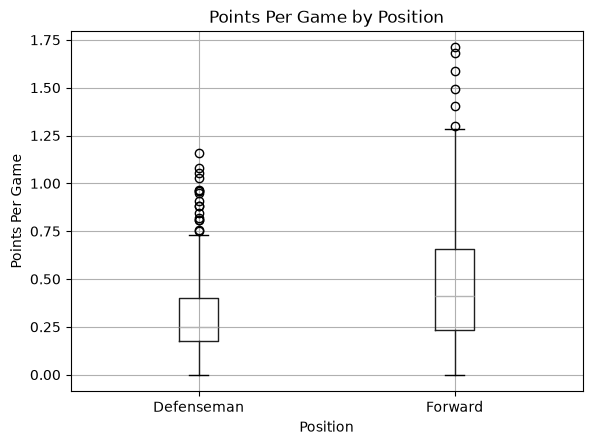

In [15]:
df_10_plus.boxplot(
    column="pointsPerGame",
    by="positionGroup"
)

plt.title("Points Per Game by Position")
plt.suptitle("")
plt.xlabel("Position")
plt.ylabel("Points Per Game")
plt.show()

- The forward distribution is shifted upward relative to defensemen.
- Both groups have high-PPG outliers.
- Forwards also show greater variability, which is consistent with the larger standard deviation we calculated (0.305 vs 0.219).

## Hypothesis test

Now we are ready to test whether that observed difference is statistically significant.

We will use a **one-sided Welch's t-test**, because:

- We have two independent groups.
- We are testing whether forwards have a higher mean.
- The groups have different sample sizes (521 vs. 259).
- Their variances are different.

In [16]:
forwards = df_10_plus[
    df_10_plus["positionGroup"] == "Forward"
]["pointsPerGame"]

defensemen = df_10_plus[
    df_10_plus["positionGroup"] == "Defenseman"
]["pointsPerGame"]

test_result = stats.ttest_ind(
    forwards,
    defensemen,
    equal_var=False,
    alternative="greater"
)

test_result

TtestResult(statistic=np.float64(8.11818803764942), pvalue=np.float64(1.1052588038634e-15), df=np.float64(682.3906860973818))

p-value ≈ 1.1 × 10<sup>-15</sup> — essentially zero. This is far below any standard threshold (even 0.001). We reject the null hypothesis with enormous confidence.
It confirms something intuitive about the game: forwards are deployed and used to score, defensemen more to prevent scoring.

## Confidence interval

Now we will calculate the 95% confidence interval for the difference in mean PPG.

In [17]:
mean_diff = forwards.mean() - defensemen.mean()

se = np.sqrt(
    forwards.var(ddof=1) / len(forwards) +
    defensemen.var(ddof=1) / len(defensemen)
)

t_critical = stats.t.ppf(
    0.975,
    df=test_result.df
)

ci_lower = mean_diff - t_critical * se
ci_upper = mean_diff + t_critical * se

print(f"mean difference: {mean_diff}\nlower bound:     {ci_lower}\nupper bound:     {ci_upper}")

mean difference: 0.1546857031695804
lower bound:     0.11727377136643198
upper bound:     0.19209763497272886


With 95% confidence, we estimate that the true difference in mean PPG between forwards and defensemen is between 0.117 and 0.192 points per game.

Also the entire interval is above zero. That is consistent with our hypothesis-test result that forwards have a higher mean PPG.

## Conclusion

The descriptive statistics show that forwards had a higher average points per game (0.422) than defensemen (0.292) during the 2025–26 regular season.

To test whether this difference was statistically significant, a one-sided Welch's t-test was conducted comparing points per game between forwards and defensemen. The results showed a statistically significant difference (p < 0.001), allowing us to reject the null hypothesis.

95% CI: 0.117–0.192 PPG

So the estimated difference is not just statistically significant—it gives us a reasonable range for the size of the difference.

**We conclude that NHL forwards had a significantly higher points-per-game average than defensemen during the 2025–26 regular season**, consistent with forwards' primary offensive role on the ice.